# What would GaiaNIR see with RCW 36?

(This is a great way to motivate presentations)

## Imports

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
from astroquery.hips2fits import hips2fits
from astroquery.simbad import Simbad
import astropy.units as u
from astropy.coordinates import Longitude, Latitude, Angle, SkyCoord
from astropy.wcs import WCS
import warnings

from ocelot.simulate import (
    SimulatedCluster,
    SimulatedClusterParameters,
    SimulatedClusterModels,
)
from gaianir_open_clusters.cluster_model import GaiaNIRObservationModel
from ocelot.model.observation import (
    GaiaDR3ObservationModel,
    GenericSubsampleSelectionFunction,
)


# Some settings for the Gaia queries
Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"
Gaia.ROW_LIMIT = 10000


# Suppress numpy warnings
_ = np.seterr(all="ignore")

## Helper

In [6]:
def download_image(
    catalogue="CDS/P/DSS2/color",
    width=1000,
    height=1000,
    ra=260.664468,
    dec=-23.8318557,
    fov=0.2,
    projection="TAN",
    coordsys="galactic",
    name=None,
):
    if isinstance(name, str):
        print("Looking up object on Simbad...")
        simbad_result = Simbad.query_object(name)
        if len(simbad_result) == 0:
            raise ValueError(
                f"Unable to find region {name} on Simbad database. Is your spelling "
                "correct?"
            )
        ra = simbad_result["ra"].to(u.deg).value[0]
        dec = simbad_result["dec"].to(u.deg).value[0]

    print("Downloading data...")
    result = hips2fits.query(
        hips=catalogue,
        width=width,
        height=height,
        ra=Longitude(ra * u.deg),
        dec=Latitude(dec * u.deg),
        fov=Angle(fov * u.deg),
        projection=projection,
        coordsys=coordsys,
    )[0]

    # Create coordinate system
    wcs = WCS(result.header).celestial

    # Transpose array if it has a color channel
    data = result.data
    if len(data.shape) > 2:
        data = np.transpose(result.data[:-1], (1, 2, 0))

    return data, wcs

In [221]:
gaia_stars = (
    Gaia.launch_job_async(
        "SELECT source_id, l, b, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, phot_g_mean_flux_error, phot_rp_mean_flux_error, phot_bp_mean_flux_error, ra, dec, pmra, pmdec, pmra_error, pmdec_error, parallax, parallax_error "
        "FROM gaiadr3.gaia_source "
        "WHERE parallax < 2 "
        f"AND l > {265 + 5 / 60} "
        f"AND l < {265 + 12 / 60} "
        f"AND b > {1 + 24 / 60} "
        f"AND b < {1 + 31 / 60} "
        "AND pmra > -10 AND pmra < -4 AND pmdec > 1 AND pmdec < 7 "
        f"AND astrometric_params_solved >= 31 "
        f"AND phot_g_mean_mag < 20 "
    )
    .get_results()
    .to_pandas()
)

INFO: Query finished. [astroquery.utils.tap.core]


## Fetch images

In [ ]:
ra = 134.865016
dec = -43.7572148
fov = 0.1
res = 2000

data_dss2, wcs = download_image(
    ra=ra,
    dec=dec,
    catalogue="CDS/P/DSS2/color",
    fov=fov,
    height=res,
    width=res,
)

In [197]:
data_ir, _ = download_image(
    ra=ra,
    dec=dec,
    catalogue="CDS/P/NEOWISER/Color",
    fov=fov,
    height=res,
    width=res,
)

## Simulate a cluster

In [166]:
position = SkyCoord(
    ra=ra * u.deg,
    dec=dec * u.deg,
    distance=954 * u.pc,
    pm_ra_cosdec=-6 * u.mas / u.yr,
    pm_dec=5 * u.mas / u.yr,
    radial_velocity=0 * u.km / u.s,
    frame="icrs",
)

parameters = SimulatedClusterParameters(
    position=position,
    mass=700,
    log_age=6,
    metallicity=0.0,
    extinction=10.,
    differential_extinction=1.,
    r_core=0.1,
    r_tidal=3,
    virial_ratio=0.5
)

In [167]:
models = SimulatedClusterModels(
    observations=[
        GaiaNIRObservationModel(
            mission_class="GaiaNIR-L", years=10, maximum_magnitude=22
        ),
        # GaiaNIRObservationModel(
        #     mission_class="Gaia",
        #     years=10,
        #     maximum_magnitude=19,
        #     combined_astrometry=False,
        # ),
        GaiaDR3ObservationModel(
            representative_stars=gaia_stars, overestimate_bp_rp_fluxes=False
        ),
    ]
)

In [168]:
cluster = SimulatedCluster(random_seed=42, parameters=parameters, models=models)
cluster.make()

/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/ocelot/model/observation/gaia/gaia_dr3.py:226: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  magnitude = -2.5 * np.log10(flux, where=good_fluxes) + self.ZEROPOINTS[band]


## Plot!

In [169]:
cluster.observations.keys()

dict_keys(['gaianir-l-10-(combined)', 'gaia_dr3'])

In [170]:
cluster.observations['gaia_dr3'] = cluster.observations['gaia_dr3'].query("gaia_dr3_g < 19")

In [202]:
data_ir.mean()

np.float64(47.87454733333333)

In [206]:
data_ir_copy.shape

(2000, 2000, 3)

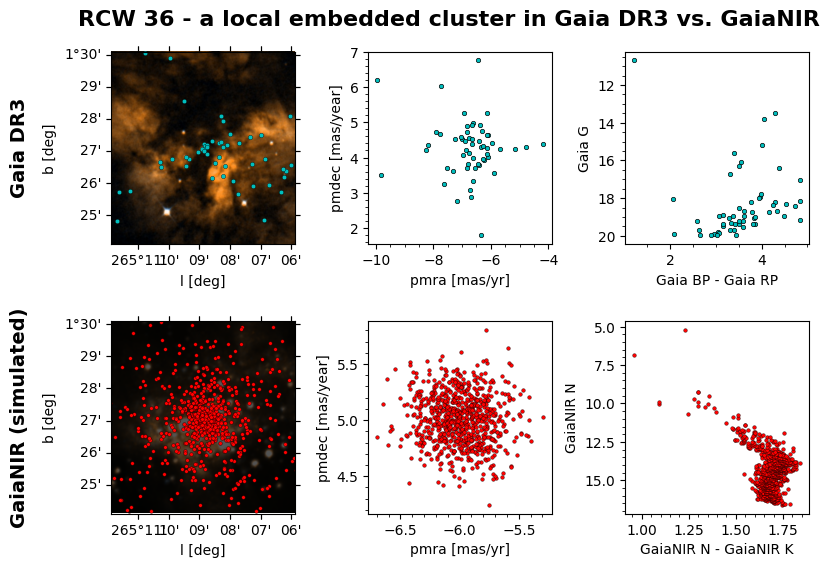

In [228]:
fig = plt.figure(figsize=(9, 6))  # , layout="constrained")

ax = []
ax.append(fig.add_subplot(2, 3, 1, projection=wcs))
ax.append(fig.add_subplot(2, 3, 2))
ax.append(fig.add_subplot(2, 3, 3))
ax.append(fig.add_subplot(2, 3, 4, projection=wcs))
ax.append(fig.add_subplot(2, 3, 5))
ax.append(fig.add_subplot(2, 3, 6))

ax[0].imshow(data_dss2, origin="lower", cmap="grey")
# data_ir_copy = data_ir.copy()
# data_ir_copy
ax[3].imshow(data_ir // 3, origin="lower", cmap="grey")


# Gaia data
xlim, ylim = ax[0].get_xlim(), ax[0].get_ylim()
ax[0].scatter(
    gaia_stars["l"],
    gaia_stars["b"],
    color="c",
    s=10,
    transform=ax[0].get_transform("world"),
    linewidths=0.25,
    edgecolors="k",
    label="Gaia DR3\n" r"(G<20, $\varpi$<2)",
)
ax[0].set(xlim=xlim, ylim=ylim)

scatter_params = dict(color="c", s=10, linewidths=0.5, edgecolors="k")
ax[1].scatter(gaia_stars["pmra"], gaia_stars["pmdec"], **scatter_params)
ax[2].scatter(
    gaia_stars["phot_bp_mean_mag"] - gaia_stars["phot_rp_mean_mag"],
    gaia_stars["phot_g_mean_mag"],
    **scatter_params,
)


# GaiaNIR
# xlim, ylim = ax[3].get_xlim(), ax[3].get_ylim()
# ax[3].scatter(
#     cluster.observations['gaia_dr3']["l"],
#     cluster.observations['gaia_dr3']["b"],
#     color="red",
#     s=10,
#     transform=ax[3].get_transform("world"),
#     linewidths=0.5,
#     edgecolors="k",
#     label="Gaia DR3\n" r"(G<20, $\varpi$<2)",
# )
# ax[3].set(xlim=xlim, ylim=ylim)
gaia_nir_stars = cluster.observations["gaianir-l-10-(combined)"]

xlim, ylim = ax[3].get_xlim(), ax[3].get_ylim()
ax[3].scatter(
    gaia_nir_stars["l"],
    gaia_nir_stars["b"],
    color="red",
    s=7,
    transform=ax[3].get_transform("world"),
    linewidths=0.25,
    edgecolors="k",
    label="Gaia DR3\n" r"(G<20, $\varpi$<2)",
)
ax[3].set(xlim=xlim, ylim=ylim)

scatter_params = dict(color="red", s=7, linewidths=0.25, edgecolors="k")
ax[4].scatter(gaia_nir_stars["pmra"], gaia_nir_stars["pmdec"], **scatter_params)
ax[5].scatter(
    gaia_nir_stars["gaianir_n"] - gaia_nir_stars["gaianir_k"],
    gaia_nir_stars["gaianir_k"],
    **scatter_params,
)

ax[2].invert_yaxis()
ax[5].invert_yaxis()

ax[0].set(aspect="auto", xlabel="l [deg]", ylabel="b [deg]")
ax[1].set(xlabel="pmra [mas/yr]", ylabel="pmdec [mas/year]")
ax[2].set(xlabel="Gaia BP - Gaia RP", ylabel="Gaia G")
ax[3].set(aspect="auto", xlabel="l [deg]", ylabel="b [deg]")
ax[4].set(xlabel="pmra [mas/yr]", ylabel="pmdec [mas/year]")
ax[5].set(xlabel="GaiaNIR N - GaiaNIR K", ylabel="GaiaNIR N")

for an_ax in ax:
    an_ax.minorticks_on()

fig.suptitle(
    "RCW 36 - a local embedded cluster in Gaia DR3 vs. GaiaNIR",
    fontweight="bold",
    fontsize=16,
    y=0.95,
)

# ax[1].set_title("RCW 36 - Gaia DR3", fontweight="bold", y=1.02, fontsize=16)
# ax[4].set_title("RCW 36 - simulated GaiaNIR observation", fontweight="bold", y=1.02, fontsize=16)
ax[0].text(
    -0.5,
    0.5,
    "Gaia DR3",
    fontweight="bold",
    ha="center",
    va="center",
    fontsize=14,
    rotation=90,
    transform=ax[0].transAxes,
)
ax[3].text(
    -0.5,
    0.5,
    "GaiaNIR (simulated)",
    fontweight="bold",
    ha="center",
    va="center",
    fontsize=14,
    rotation=90,
    transform=ax[3].transAxes,
)

fig.subplots_adjust(wspace=0.4, hspace=0.4)

fig.savefig(
    "figs_presentations/rcw_36_gaia_vs_gaianir.png", dpi=300, bbox_inches="tight"
)

n.b. this plot does NOT include the impact of crowding yet.